# World Happiness Report Analysis — 02 Analysis

Which factors actually track happiness, and who's top/bottom?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()

## 1. Happiest & least-happy countries

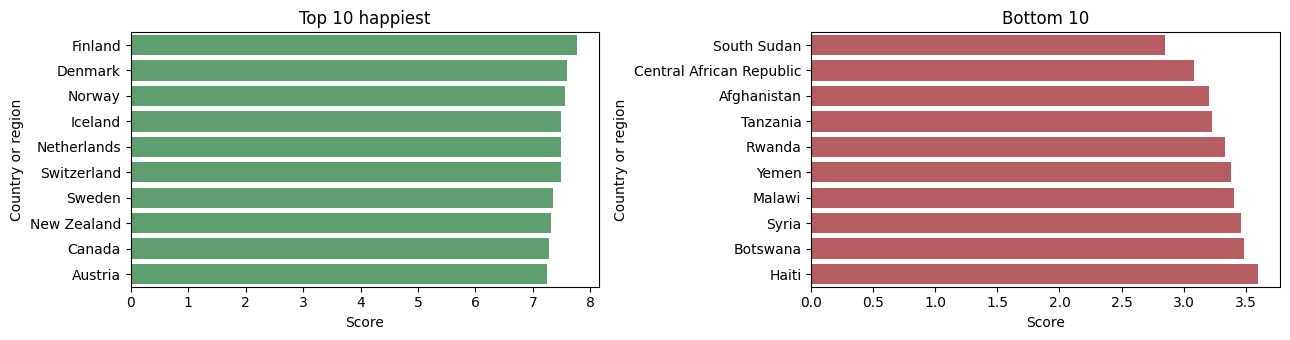

In [2]:
top=df.nsmallest(10,'Overall rank'); bot=df.nlargest(10,'Overall rank')
fig,ax=plt.subplots(1,2,figsize=(13,3.5))
sns.barplot(y='Country or region',x='Score',data=top,ax=ax[0],color='#55a868'); ax[0].set_title('Top 10 happiest')
sns.barplot(y='Country or region',x='Score',data=bot,ax=ax[1],color='#c44e52'); ax[1].set_title('Bottom 10')
plt.tight_layout(); plt.show()

## 2. What correlates with happiness?

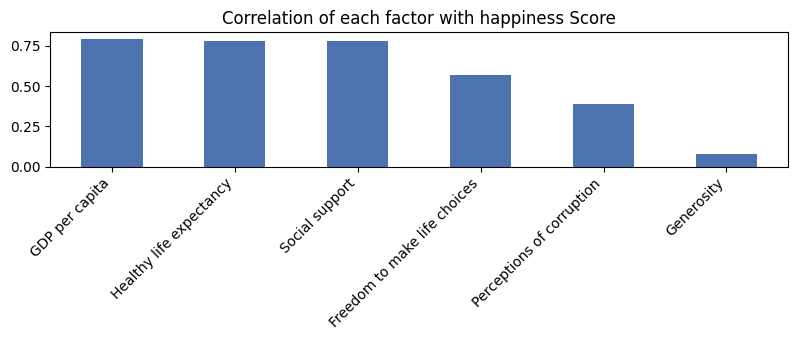

GDP per capita                  0.794
Healthy life expectancy         0.780
Social support                  0.777
Freedom to make life choices    0.567
Perceptions of corruption       0.386
Generosity                      0.076


In [3]:
factors=['GDP per capita','Social support','Healthy life expectancy','Freedom to make life choices','Perceptions of corruption','Generosity']
cor=df[['Score']+factors].corr()['Score'].drop('Score').sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(8,3.5)); cor.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('Correlation of each factor with happiness Score'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(cor.round(3).to_string())

## 3. GDP vs Score (with the strongest driver)

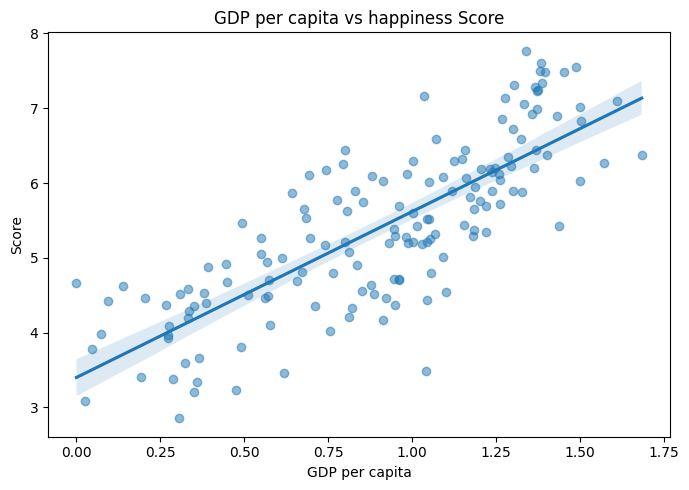

In [4]:
fig,ax=plt.subplots(figsize=(7,5))
sns.regplot(x='GDP per capita',y='Score',data=df,ax=ax,scatter_kws={'alpha':0.5})
ax.set_title('GDP per capita vs happiness Score'); plt.tight_layout(); plt.show()

## 4. Correlation heatmap

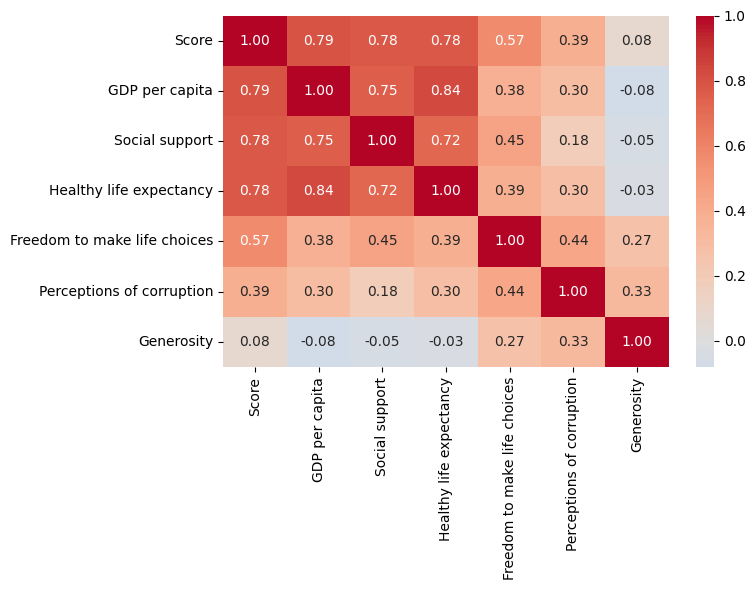

In [5]:
fig,ax=plt.subplots(figsize=(8,6)); sns.heatmap(df[['Score']+factors].corr(),annot=True,fmt='.2f',cmap='coolwarm',center=0,ax=ax); plt.tight_layout(); plt.show()

## 5. Key findings

- **Happiest: Finland, Denmark, Norway; least: South Sudan, Central African Republic, Afghanistan.**
- **Economy + health + social support dominate**: Score correlates 0.79 with GDP per capita, 0.78 with healthy life expectancy, 0.78 with social support.
- **Freedom matters moderately** (0.57); **corruption weakly** (0.39).
- **Generosity barely correlates (0.08)** — being generous is not what makes a *country* score high; material and social security do.
- Policy read: happiness is largely explained by wealth, health, and having someone to count on.